# Final Instance Segmentation với YOLOv8

Notebook sử dụng dataset từ Roboflow: https://universe.roboflow.com/alebachew-m/final_instance_segmentation

## 1. Cài đặt thư viện

In [1]:
!pip install ultralytics roboflow -q


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import thư viện

In [2]:
import os
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from roboflow import Roboflow
from ultralytics import YOLO

# Kiểm tra GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cpu
CUDA available: False


## 3 Tải dữ liệu

Đoạn code sử dụng Roboflow API để tải dataset instance segmentation đã được gán nhãn. Dataset final_instance_segmentation chứa ảnh lá đậu với polygon annotations cho 3 lớp bệnh. Trước khi download, script kiểm tra và xóa thư mục cũ để tránh conflict. Dataset được tải về với format YOLOv8 (bao gồm file data.yaml và cấu trúc thư mục train/valid/test), sẵn sàng cho training với Ultralytics YOLOv8-seg model.

In [3]:
# Nhập API key của bạn
ROBOFLOW_API_KEY = "Efp5ZmBckO5PsBl99j41"  # Thay bằng API key của bạn

# Khởi tạo Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Tải dataset
project = rf.workspace("alebachew-m").project("final_instance_segmentation")
version = project.version(1)  # Thay đổi version nếu cần

# Xóa thư mục cũ nếu tồn tại để tránh lỗi
dataset_path = Path("./final_instance_segmentation-1")
if dataset_path.exists():
    shutil.rmtree(dataset_path)
    print(f"Đã xóa thư mục cũ: {dataset_path}")

# Download dataset với format YOLOv8
dataset = version.download("yolov8")
print(f"Dataset location: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final_Instance_Segmentation-1 in yolov8:: 100%|██████████| 6738/6738 [00:05<00:00, 1210.39it/s]

Dataset location: d:\DataMining\DoAnFinal\Final_Instance_Segmentation-1


## 4. Khám phá Dataset

In [4]:
# Đọc file data.yaml
import yaml

data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("=" * 50)
print("CẤU HÌNH DATASET")
print("=" * 50)
print(f"Số lượng classes: {data_config.get('nc', 'N/A')}")
print(f"Tên các classes: {data_config.get('names', 'N/A')}")
print(f"Train path: {data_config.get('train', 'N/A')}")
print(f"Val path: {data_config.get('val', 'N/A')}")
print(f"Test path: {data_config.get('test', 'N/A')}")

CẤU HÌNH DATASET
Số lượng classes: 3
Tên các classes: ['Angular_Leaf_Spot', 'Bean_Rust', 'Healthy']
Train path: ../train/images
Val path: ../valid/images
Test path: ../test/images


In [5]:
# Đếm số lượng ảnh trong mỗi tập
def count_images(folder):
    if not os.path.exists(folder):
        return 0
    return len([f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))])

train_images = os.path.join(dataset.location, "train", "images")
val_images = os.path.join(dataset.location, "valid", "images")
test_images = os.path.join(dataset.location, "test", "images")

print(f"\nSố lượng ảnh:")
print(f"  - Train: {count_images(train_images)}")
print(f"  - Validation: {count_images(val_images)}")
print(f"  - Test: {count_images(test_images)}")


Số lượng ảnh:
  - Train: 3102
  - Validation: 133
  - Test: 128


Dataset gồm tổng cộng 3,363 ảnh lá đậu được gán nhãn polygon segmentation, phân chia thành 3 tập

PHÂN BỐ LỚP DỮ LIỆU
angular_leaf_spot: Train=31383 | Valid=1292 | Test=1283 | Total=33958
bean_rust: Train=16381 | Valid=691 | Test=773 | Total=17845
healthy: Train=1281 | Valid=53 | Test=49 | Total=1383


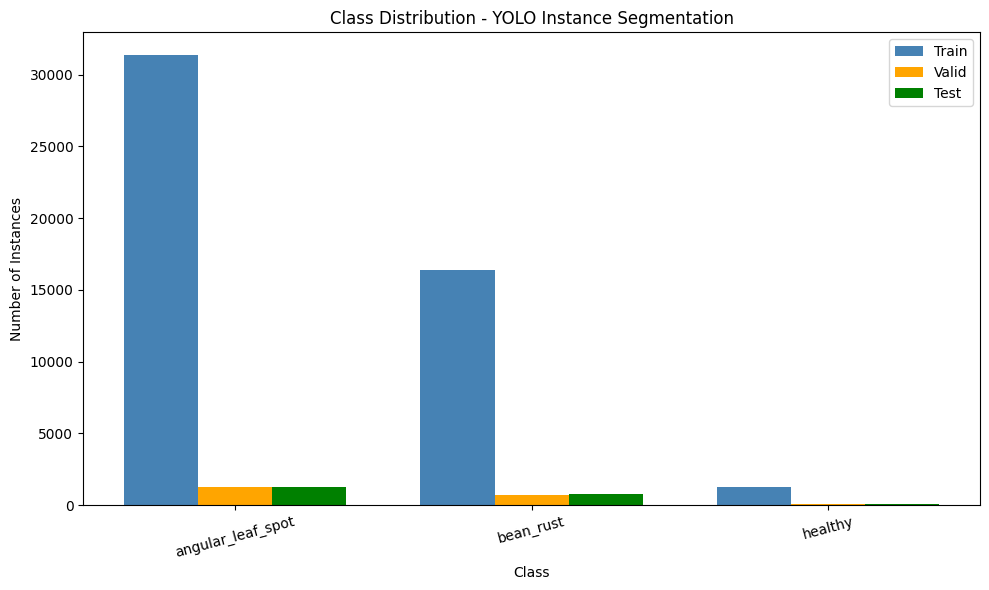

In [11]:
import os
from collections import Counter

dataset_path = Path('D:/DataMining/DoAnFinal/Final_Instance_Segmentation-1')
# Nếu chạy trên Kaggle thì đổi thành:
# dataset_path = Path('/kaggle/input/final-instance-segmentation-1')

class_names = ['angular_leaf_spot', 'bean_rust', 'healthy']
split_counts = {'train': Counter(), 'valid': Counter(), 'test': Counter()}

for split in ['train', 'valid', 'test']:
    label_dir = dataset_path / split / 'labels'
    if label_dir.exists():
        for label_file in label_dir.glob('*.txt'):
            with open(label_file, 'r') as f:
                for line in f:
                    if line.strip():
                        class_id = int(line.strip().split()[0])
                        split_counts[split][class_id] += 1


print("PHÂN BỐ LỚP DỮ LIỆU")

for class_id, class_name in enumerate(class_names):
    t, v, te = split_counts['train'].get(class_id,0), split_counts['valid'].get(class_id,0), split_counts['test'].get(class_id,0)
    print(f"{class_name}: Train={t} | Valid={v} | Test={te} | Total={t+v+te}")

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(class_names))
width = 0.25
train_vals = [split_counts['train'].get(i, 0) for i in range(len(class_names))]
valid_vals = [split_counts['valid'].get(i, 0) for i in range(len(class_names))]
test_vals = [split_counts['test'].get(i, 0) for i in range(len(class_names))]

ax.bar([i - width for i in x], train_vals, width, label='Train', color='steelblue')
ax.bar(x, valid_vals, width, label='Valid', color='orange')
ax.bar([i + width for i in x], test_vals, width, label='Test', color='green')

ax.set_xlabel('Class'); ax.set_ylabel('Number of Instances')
ax.set_title('Class Distribution - YOLO Instance Segmentation')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=15)
ax.legend(); plt.tight_layout(); plt.show()

Dataset có sự mất cân bằng rõ rệt giữa các lớp: angular_leaf_spot chiếm đa số (63.8%), tiếp theo là bean_rust (33.6%), trong khi healthy chỉ chiếm 2.6%. Điều này phản ánh thực tế rằng ảnh lá bệnh thường chứa nhiều vùng tổn thương (trung bình 10-15 instances/ảnh),


Ảnh mẫu từ tập Train:


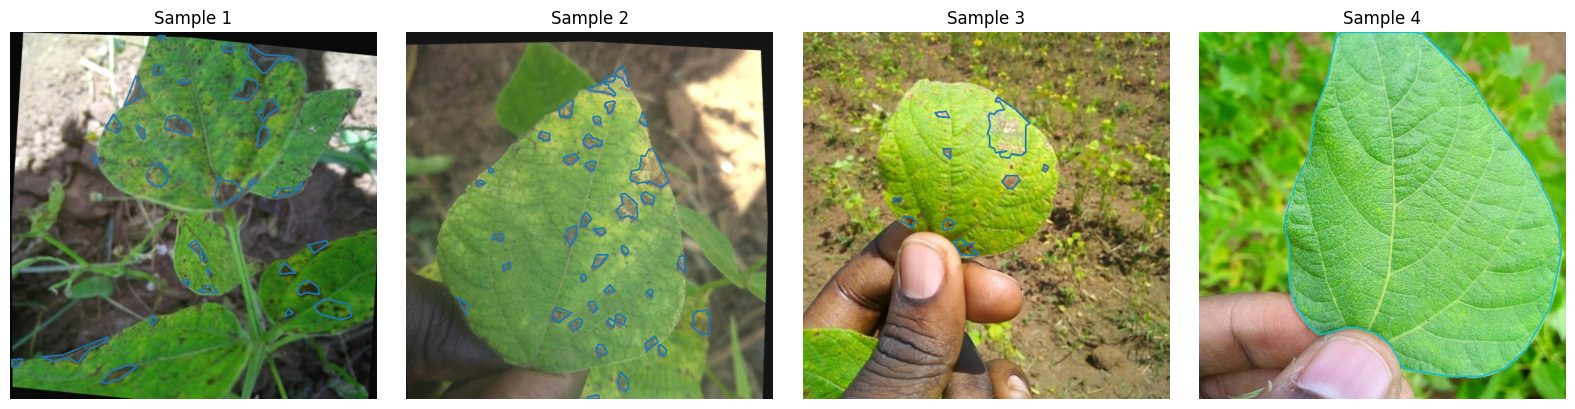

In [6]:
# Hiển thị một số ảnh mẫu
def show_sample_images(images_path, labels_path, class_names, num_samples=4):
    """Hiển thị ảnh mẫu với annotations"""
    if not os.path.exists(images_path):
        print(f"Không tìm thấy thư mục: {images_path}")
        return
    
    image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_files = image_files[:num_samples]
    
    fig, axes = plt.subplots(1, len(sample_files), figsize=(16, 4))
    if len(sample_files) == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for idx, (ax, img_file) in enumerate(zip(axes, sample_files)):
        # Đọc ảnh
        img_path = os.path.join(images_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Đọc label
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_path, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:  # class + polygon points
                        class_id = int(parts[0])
                        # Chuyển đổi polygon points
                        points = list(map(float, parts[1:]))
                        polygon = np.array(points).reshape(-1, 2)
                        polygon[:, 0] *= w
                        polygon[:, 1] *= h
                        polygon = polygon.astype(np.int32)
                        
                        # Vẽ polygon
                        color = tuple(int(c * 255) for c in colors[class_id % len(colors)][:3])
                        cv2.polylines(img, [polygon], True, color, 2)
        
        ax.imshow(img)
        ax.set_title(f"Sample {idx + 1}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Hiển thị ảnh mẫu từ tập train
train_labels = os.path.join(dataset.location, "train", "labels")
class_names = data_config.get('names', [])

print("\nẢnh mẫu từ tập Train:")
show_sample_images(train_images, train_labels, class_names)

## 5. Huấn luyện Model YOLOv8 Instance Segmentation

In [7]:
# Cấu hình huấn luyện
MODEL_SIZE = "n"  # n, s, m, l, x (nano -> xlarge)
EPOCHS = 100
BATCH_SIZE = 16  # Giảm nếu gặp lỗi bộ nhớ
IMAGE_SIZE = 640
PATIENCE = 20  # Early stopping

# Tạo model
model = YOLO(f"yolov8{MODEL_SIZE}-seg.pt")

print(f"\nCẤU HÌNH HUẤN LUYỆN:")
print(f"  - Model: YOLOv8{MODEL_SIZE}-seg")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Image size: {IMAGE_SIZE}")
print(f"  - Early stopping patience: {PATIENCE}")


CẤU HÌNH HUẤN LUYỆN:
  - Model: YOLOv8n-seg
  - Epochs: 100
  - Batch size: 16
  - Image size: 640
  - Early stopping patience: 20


Model YOLOv8n-seg (nano, 3.2M parameters) được sử dụng để cân bằng giữa tốc độ inference và độ chính xác. Training được cấu hình với 100 epochs tối đa, batch size 16, và image size 640×640 pixels. Early stopping với patience=20 epochs sẽ tự động dừng training nếu model không cải thiện, giúp tránh overfitting và tiết kiệm thời gian. Phiên bản nano phù hợp cho deployment trên các thiết bị edge và inference realtime.

Model được huấn luyện với pretrained weights từ COCO dataset, sử dụng GPU nếu khả dụng. Checkpoint được lưu mỗi 10 epochs để backup. Data augmentation được áp dụng mạnh mẽ để tăng tính đa dạng: điều chỉnh HSV (hue 1.5%, saturation 70%, value 40%), biến đổi hình học (xoay ±10°, dịch chuyển 10%, scale 50%, shear 5°), lật ngang 50%, và Mosaic augmentation (ghép 4 ảnh thành 1) cùng MixUp (trộn 2 ảnh với tỷ lệ 10%). Các kỹ thuật này giúp model robust hơn với các biến thể về góc chụp, ánh sáng và kích thước vùng bệnh trong thực tế.

In [8]:
# Huấn luyện model
results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMAGE_SIZE,
    patience=PATIENCE,
    save=True,
    save_period=10,  # Lưu checkpoint mỗi 10 epochs
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=4,
    exist_ok=True,
    pretrained=True,
    optimizer='auto',
    verbose=True,
    seed=42,
    deterministic=True,
    # Data augmentation
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    shear=5.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
)

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Final_Instance_Segmentation-1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

Model phân đoạn lá khỏe mạnh rất tốt (mAP50 ~95%) do boundary rõ ràng. Ngược lại, bean_rust có kết quả thấp nhất (mAP50 ~42%) do vùng bệnh nhỏ và dễ nhầm với angular_leaf_spot. Tốc độ inference đạt 4.9ms/ảnh, phù hợp cho ứng dụng realtime. Overall Mask mAP50-95 đạt 45.9% - kết quả khá tốt cho bài toán instance segmentation với nhiều vùng bệnh nhỏ chồng chéo.

## 6. Đánh giá Model

In [9]:
# Load model tốt nhất
best_model_path = os.path.join(results.save_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)
print(f"Đã load model từ: {best_model_path}")

Đã load model từ: /kaggle/working/runs/segment/train/weights/best.pt


In [10]:
# Đánh giá trên tập validation
val_results = best_model.val(
    data=data_yaml_path,
    split='val',
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    conf=0.25,
    iou=0.6,
    device=0 if torch.cuda.is_available() else 'cpu',
)

print("\n" + "=" * 50)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION")
print("=" * 50)
print(f"Box mAP@0.5: {val_results.box.map50:.4f}")
print(f"Box mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Mask mAP@0.5: {val_results.seg.map50:.4f}")
print(f"Mask mAP@0.5:0.95: {val_results.seg.map:.4f}")

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1511.9±776.0 MB/s, size: 71.3 KB)
val: Scanning /kaggle/working/Final_Instance_Segmentation-1/valid/labels.cache... 133 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 133/133 55.8Mit/s 0.0s
val: /kaggle/working/Final_Instance_Segmentation-1/valid/images/angular_leaf_spot_val-34_jpg.rf.05dba808bb9782ee9d5e73c8725c08f7.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.2s/it 10.4s
                   all        133       2035      0.689      0.676       0.73      0.558      0.652      0.631      0.683      0.484
     Angular_Leaf_Spot         44       1291      0.699      0.638      0.702      0.475      0.664      0.588 

Lớp healthy đạt kết quả xuất sắc (Mask mAP50 ~93%) do vùng segmentation là toàn bộ lá với boundary rõ ràng. Lớp bean_rust có recall thấp nhất (37.9%) do các đốm gỉ sắt nhỏ và màu sắc tương đồng với nền lá. Tổng thể, model đạt Mask mAP50-95 = 48.4% - kết quả tốt cho bài toán instance segmentation với nhiều vùng bệnh nhỏ và chồng chéo.

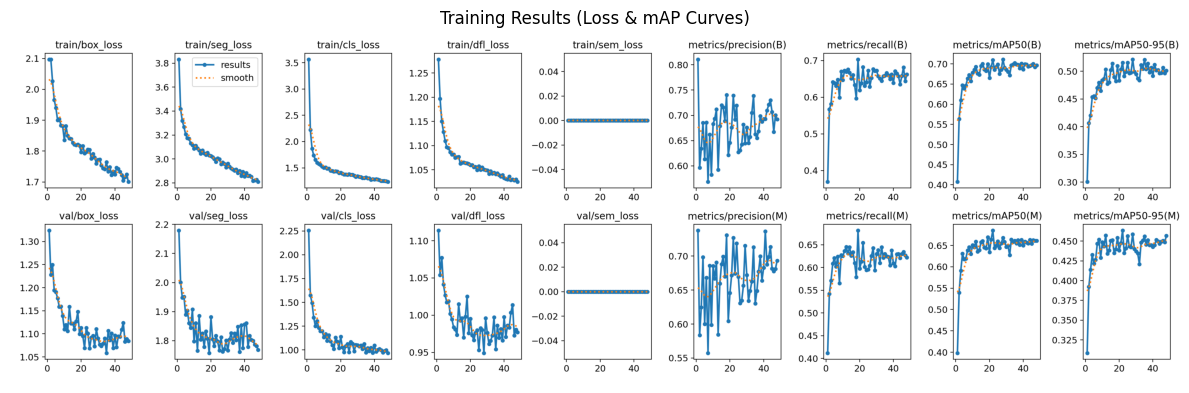

In [11]:
# Hiển thị biểu đồ Loss và mAP
from PIL import Image
import os

# Đường dẫn kết quả training (thay đổi nếu cần)
results_dir = "/kaggle/working/runs/segment/train"

# Training results
results_path = os.path.join(results_dir, 'results.png')
if os.path.exists(results_path):
    img = Image.open(results_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title('Training Results (Loss & mAP Curves)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"results.png not found at {results_path}")

Biểu đồ cho thấy quá trình training ổn định qua 48 epochs:

Loss Curves (hàng trên): Tất cả các loss (box, seg, cls, dfl) giảm đều đặn và hội tụ, cho thấy model học tốt. train/sem_loss = 0 vì không sử dụng semantic segmentation head.

Validation Curves (hàng dưới): Loss giảm song song với training, không có dấu hiệu overfitting. Các metrics (Precision, Recall, mAP50, mAP50-95) tăng dần và ổn định ở mức 0.65-0.75.

Nhận xét: Model hội tụ tốt với gap nhỏ giữa train và validation loss. Early Stopping kích hoạt tại epoch 48 (best ở epoch 28) là hợp lý khi các metrics không còn cải thiện đáng kể. Kết quả cuối cùng đạt Mask mAP50 ~68% và Mask mAP50-95 ~48%.

## 7. Prediction và Visualization

In [12]:
# Dự đoán trên một số ảnh test
test_images_path = os.path.join(dataset.location, "test", "images")
if not os.path.exists(test_images_path):
    test_images_path = os.path.join(dataset.location, "valid", "images")

# Lấy một số ảnh để test
test_files = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))][:6]

print(f"Dự đoán trên {len(test_files)} ảnh từ: {test_images_path}")

Dự đoán trên 6 ảnh từ: /kaggle/working/Final_Instance_Segmentation-1/test/images



image 1/1 /kaggle/working/Final_Instance_Segmentation-1/test/images/angular_leaf_spot_test-36_jpg.rf.d2e1da97a157f8c19d31fb46d25b59f6.jpg: 640x640 21 Angular_Leaf_Spots, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 21.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/Final_Instance_Segmentation-1/test/images/angular_leaf_spot_test-11_jpg.rf.f896ab95f9b06b5cf0f9b2d9fd583fdc.jpg: 640x640 53 Angular_Leaf_Spots, 10.2ms
Speed: 1.8ms preprocess, 10.2ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/Final_Instance_Segmentation-1/test/images/healthy_test-6_jpg.rf.2a5f2c5de4274d36f0412d14ed39115e.jpg: 640x640 3 Healthys, 7.7ms
Speed: 1.6ms preprocess, 7.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/Final_Instance_Segmentation-1/test/images/angular_leaf_spot_test-17_jpg.rf.4f89f3058f2c126d25b125dee22ccd49.jpg: 640x640 58 Angular_Leaf_Spots, 7.8ms
Speed: 1.7ms preprocess

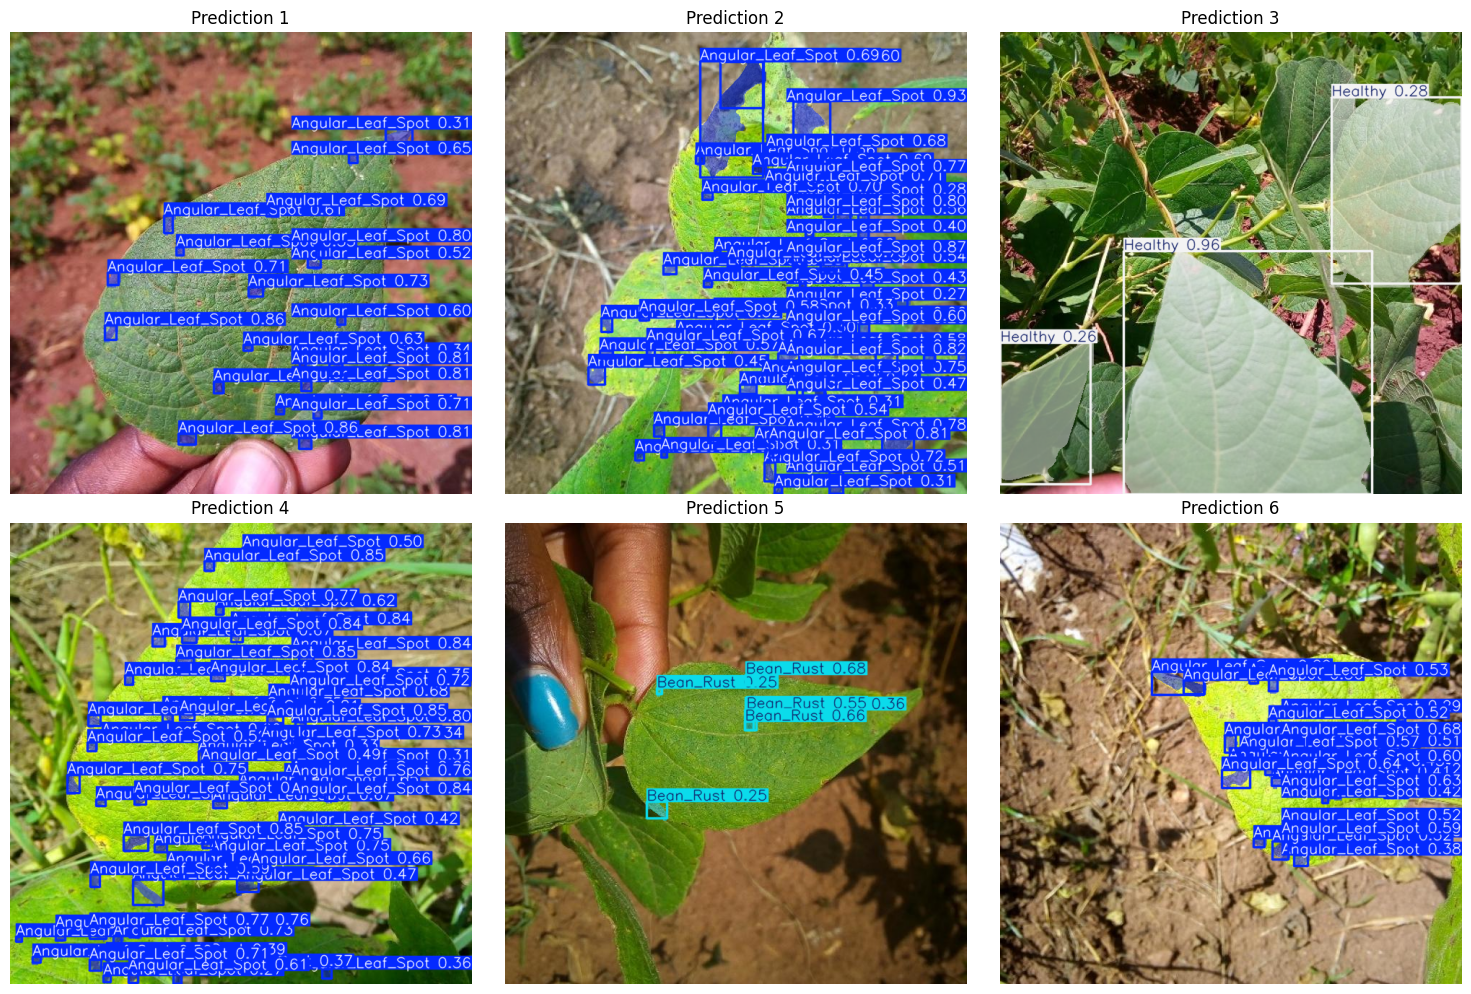

Đã lưu kết quả vào: prediction_results.png


In [13]:
# Thực hiện prediction và hiển thị kết quả
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (ax, img_file) in enumerate(zip(axes, test_files)):
    img_path = os.path.join(test_images_path, img_file)
    
    # Dự đoán
    results = best_model.predict(
        source=img_path,
        conf=0.25,
        iou=0.5,
        imgsz=IMAGE_SIZE,
        device=0 if torch.cuda.is_available() else 'cpu',
    )
    
    # Lấy ảnh với kết quả đã vẽ
    result_img = results[0].plot()
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(result_img)
    ax.set_title(f"Prediction {idx + 1}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu kết quả vào: prediction_results.png")

## 8. Export Model

In [14]:
# Export model sang ONNX format
onnx_path = best_model.export(format='onnx', imgsz=IMAGE_SIZE, simplify=True)
print(f"\nĐã export model sang ONNX: {onnx_path}")

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/segment/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 39, 8400), (1, 32, 160, 160)) (6.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 265ms
Prepared 4 packages in 2.89s
Installed 4 packages in 17ms
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 4.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.0 op

Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 5.6s, saved as '/kaggle/working/runs/segment/train/weights/best.onnx' (12.7 MB)

Export complete (6.0s)
Results saved to /kaggle/working/runs/segment/train/weights
Predict:         yolo predict task=segment model=/kaggle/working/runs/segment/train/weights/best.onnx imgsz=640  
Validate:        yolo val task=segment model=/kaggle/working/runs/segment/train/weights/best.onnx imgsz=640 data=/kaggle/working/Final_Instance_Segmentation-1/data.yaml  
Visualize:       https://netron.app

Đã export model sang ONNX: /kaggle/working/runs/segment/train/weights/best.onnx


In [15]:
# Lưu model cuối cùng
final_model_path = "./final_instance_segmentation_model.pt"
shutil.copy(best_model_path, final_model_path)
print(f"Đã lưu model cuối cùng vào: {final_model_path}")

Đã lưu model cuối cùng vào: ./final_instance_segmentation_model.pt


## 9. Thử nghiệm với ảnh mới


image 1/1 /kaggle/working/Final_Instance_Segmentation-1/test/images/angular_leaf_spot_test-36_jpg.rf.d2e1da97a157f8c19d31fb46d25b59f6.jpg: 640x640 21 Angular_Leaf_Spots, 8.1ms
Speed: 1.7ms preprocess, 8.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


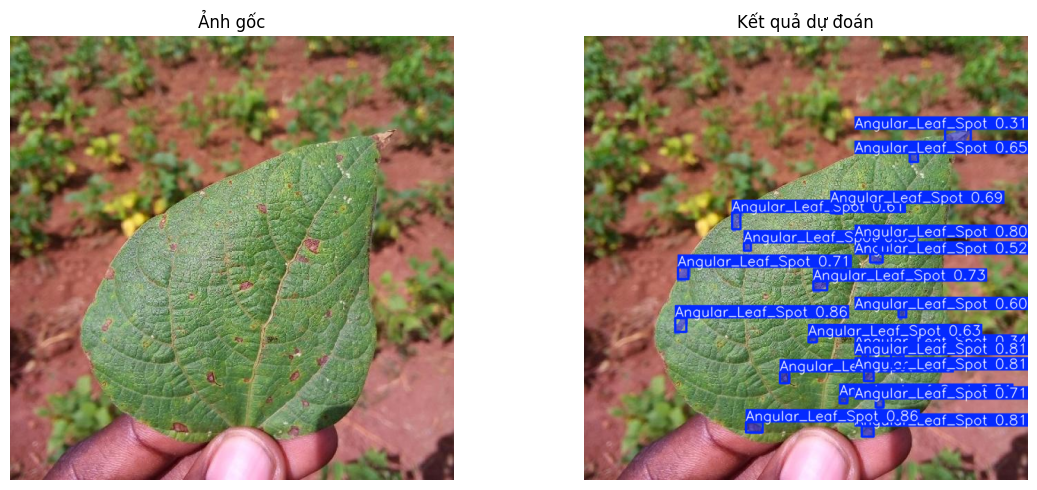


Thông tin chi tiết:
  [1] Angular_Leaf_Spot: confidence = 86.33%
  [2] Angular_Leaf_Spot: confidence = 86.08%
  [3] Angular_Leaf_Spot: confidence = 81.31%
  [4] Angular_Leaf_Spot: confidence = 80.60%
  [5] Angular_Leaf_Spot: confidence = 80.58%
  [6] Angular_Leaf_Spot: confidence = 80.16%
  [7] Angular_Leaf_Spot: confidence = 76.38%
  [8] Angular_Leaf_Spot: confidence = 72.83%
  [9] Angular_Leaf_Spot: confidence = 70.93%
  [10] Angular_Leaf_Spot: confidence = 70.79%
  [11] Angular_Leaf_Spot: confidence = 68.91%
  [12] Angular_Leaf_Spot: confidence = 64.86%
  [13] Angular_Leaf_Spot: confidence = 62.56%
  [14] Angular_Leaf_Spot: confidence = 60.61%
  [15] Angular_Leaf_Spot: confidence = 59.73%
  [16] Angular_Leaf_Spot: confidence = 54.86%
  [17] Angular_Leaf_Spot: confidence = 51.95%
  [18] Angular_Leaf_Spot: confidence = 51.07%
  [19] Angular_Leaf_Spot: confidence = 34.11%
  [20] Angular_Leaf_Spot: confidence = 31.46%
  [21] Angular_Leaf_Spot: confidence = 31.01%


In [16]:
def predict_single_image(model, image_path, conf=0.25):
    """Dự đoán trên một ảnh và hiển thị kết quả"""
    # Dự đoán
    results = model.predict(
        source=image_path,
        conf=conf,
        iou=0.5,
        imgsz=IMAGE_SIZE,
        device=0 if torch.cuda.is_available() else 'cpu',
    )
    
    # Hiển thị
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Ảnh gốc
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    axes[0].imshow(original)
    axes[0].set_title("Ảnh gốc")
    axes[0].axis('off')
    
    # Ảnh kết quả
    result_img = results[0].plot()
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
    axes[1].imshow(result_img)
    axes[1].set_title("Kết quả dự đoán")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # In thông tin chi tiết
    print("\nThông tin chi tiết:")
    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            for i, (box, cls, conf) in enumerate(zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf)):
                class_name = class_names[int(cls)] if int(cls) < len(class_names) else f"Class {int(cls)}"
                print(f"  [{i+1}] {class_name}: confidence = {conf:.2%}")
        else:
            print("  Không phát hiện đối tượng nào.")
    
    return results

# Thử với một ảnh mẫu
sample_image = os.path.join(test_images_path, test_files[0])
_ = predict_single_image(best_model, sample_image)